In [27]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF
from gpzoo.gp import GaussianPrior, SVGP, MGGP_VNNGP, MGGP_WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import  whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, plot_factors, rescale_spatial_coords, add_jitter, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans

import matplotlib.patheffects as path_effects
import gc
from matplotlib.legend_handler import HandlerPathCollection


In [28]:
adata = sq.datasets.slideseqv2()
adata = adata.raw.to_adata()

<Axes: >

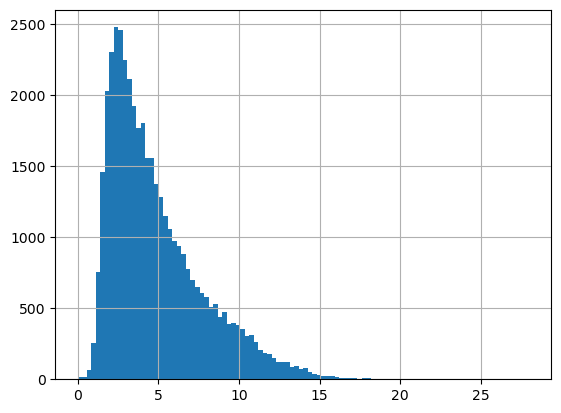

In [29]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.pct_counts_mt.hist(bins=100)


In [5]:
adata = adata[adata.obs.pct_counts_mt < 20] #from 53K to 45K
sc.pp.filter_cells(adata, min_counts=100)#was 100
sc.pp.filter_genes(adata, min_cells=10)# was 10

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [6]:
Dtr, Dval = anndata_to_train_val(adata, sz="scanpy")

In [7]:
Y = Dtr['Y'].T
Y = Y[~adata.var.MT]
X = Dtr['X']*50
V = Dtr['sz']

In [10]:
adata.

{'X': array([[-0.7172934 , -1.4694495 ],
        [ 1.493829  , -0.6859524 ],
        [-0.72874284, -0.10706067],
        ...,
        [-0.16105318, -0.94146204],
        [ 0.0152173 ,  0.2500105 ],
        [ 1.3316436 ,  0.9605284 ]], dtype=float32),
 'Y': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 'sz': array([[1.0779436 ],
        [1.0586867 ],
        [1.1150992 ],
        ...,
        [1.0690609 ],
        [1.1256998 ],
        [0.97100043]], dtype=float32)}

In [8]:
groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.cluster.values.categories)

/tmp/ipykernel_435375/395734616.py:19: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


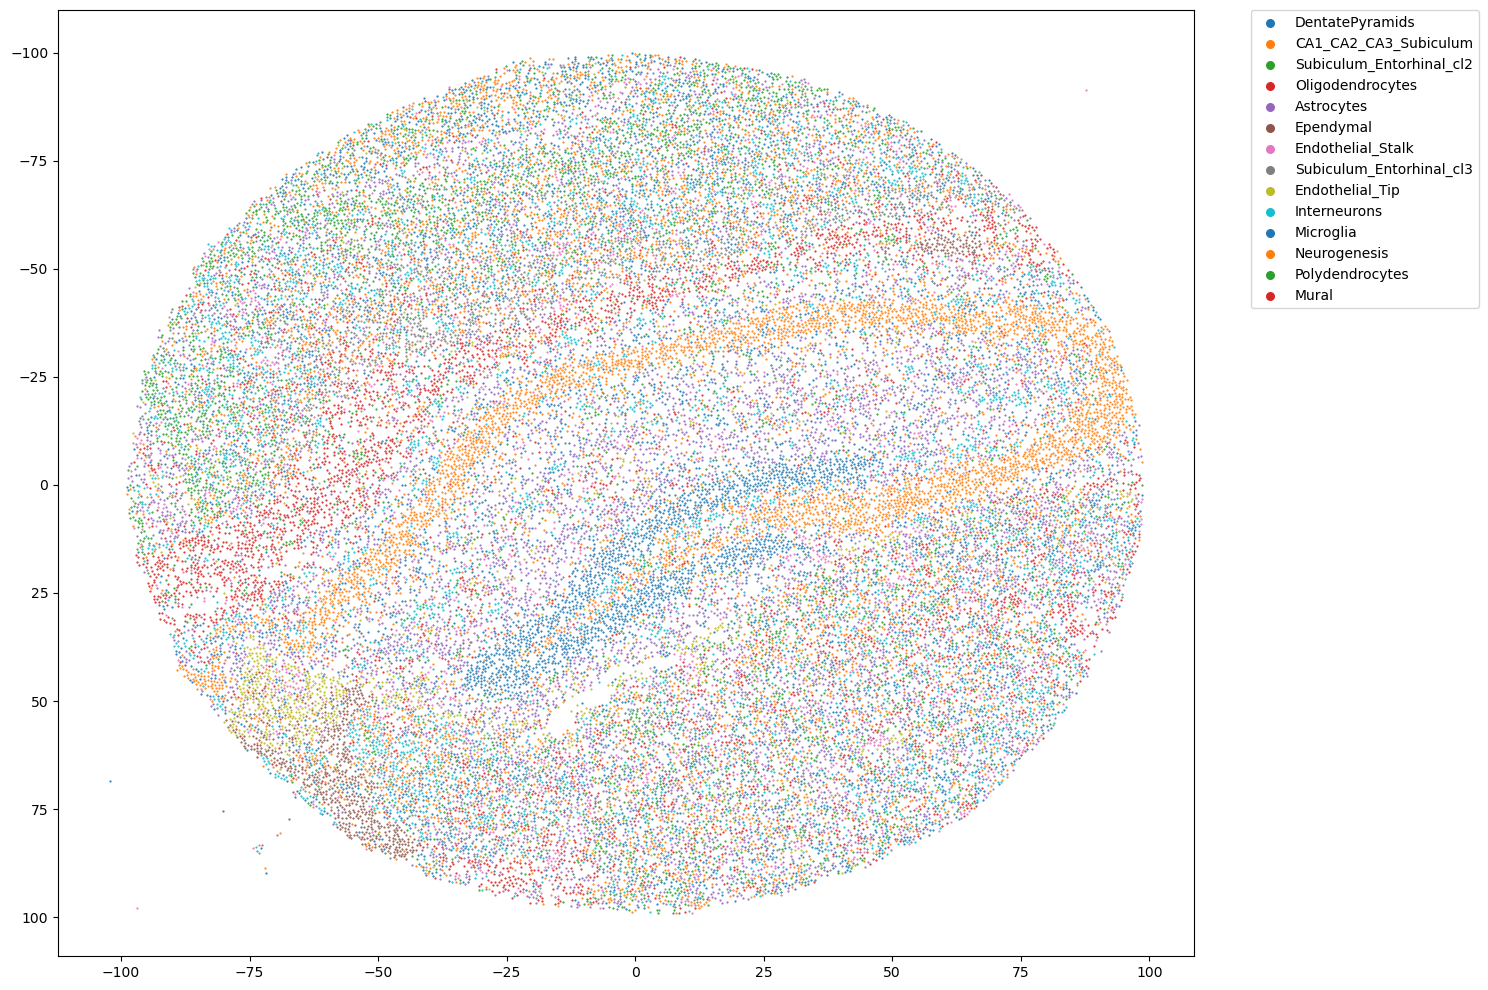

In [32]:
plt.figure(figsize=(15, 10))
for class_label in adata.obs.cluster.unique():
    idx = class_label == adata[Dtr['idx']].obs.cluster    
    plt.scatter(X[idx][::, 0], X[idx][::, 1], s=0.3, label=class_label)
    
plt.gca().invert_yaxis()


# Create legend first
legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=1,
    scatterpoints=1
)

# Set larger marker size for each legend handle
for handle in legend.legendHandles:
    handle.set_sizes([30])  # Change 30 to any desired size

plt.tight_layout()
plt.show()

/tmp/ipykernel_435375/1762123335.py:19: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


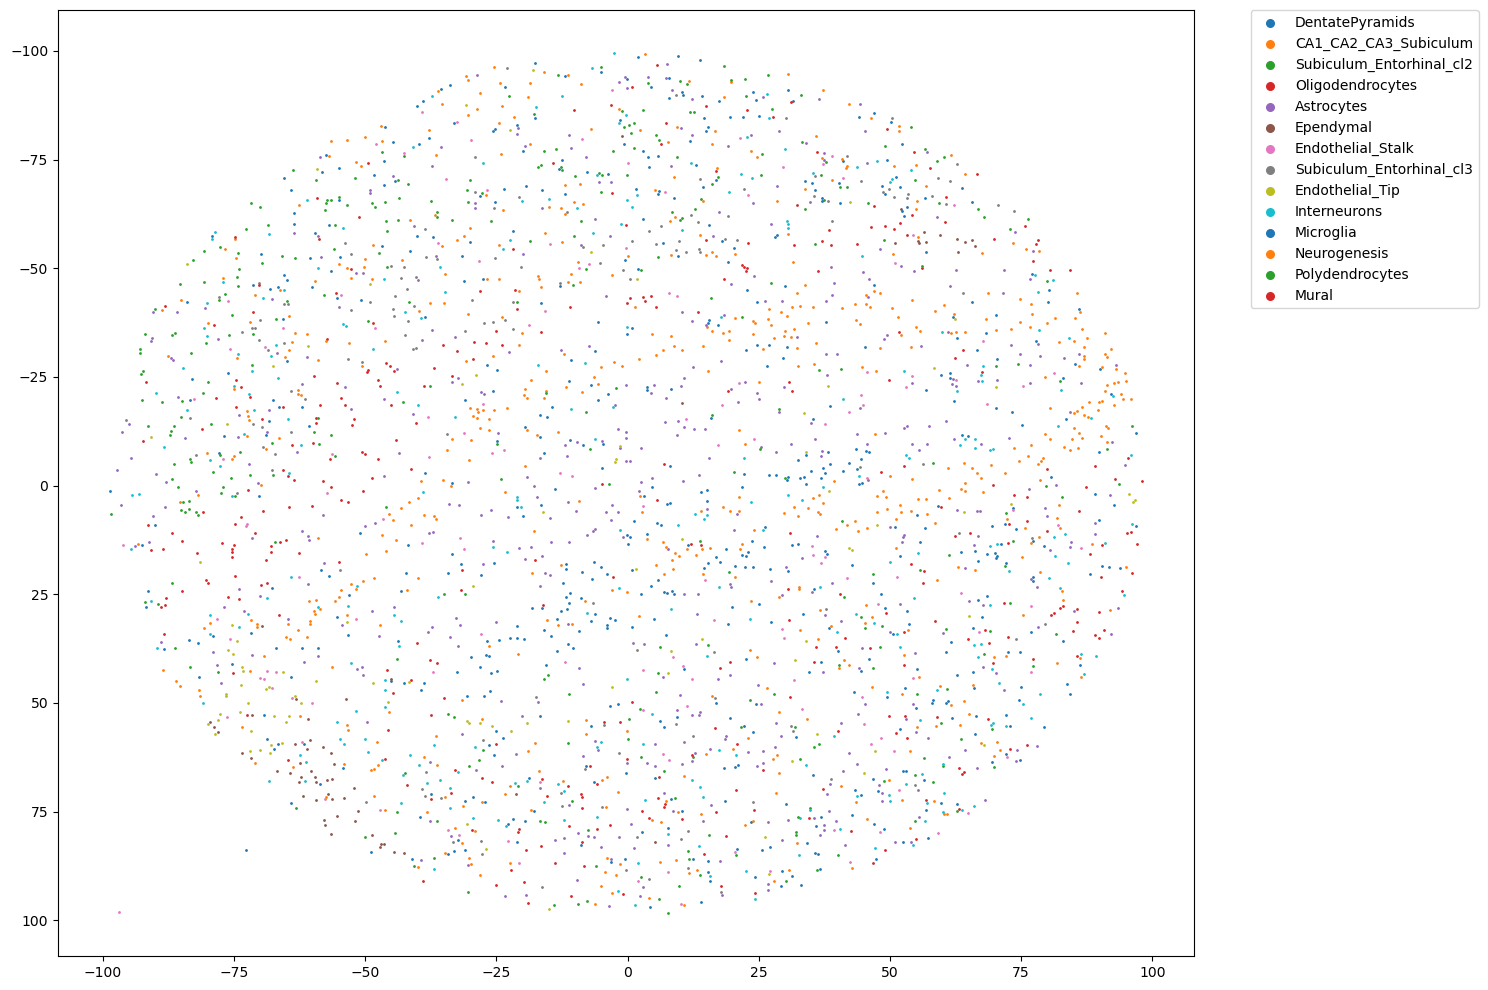

In [48]:
plt.figure(figsize=(15, 10))
for class_label in adata.obs.cluster.unique():
    idx = class_label == adata[Dtr['idx']].obs.cluster    
    plt.scatter(X[idx][::13, 0], X[idx][::13, 1], s=1.0, label=class_label)
    
plt.gca().invert_yaxis()


# Create legend first
legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=1,
    scatterpoints=1
)

# Set larger marker size for each legend handle
for handle in legend.legendHandles:
    handle.set_sizes([30])  # Change 30 to any desired size

plt.tight_layout()
plt.show()